# 04 — ANN Crop Recommendation
### Training the core Artificial Neural Network classifier



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

np.random.seed(42)
tf.random.set_seed(42)

PROC_DIR = '../data/processed'
MODEL_DIR = '../models'


I0000 00:00:1788810630.372124    2782 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788810630.420956    2782 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788810631.651650    2782 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Benchmark ANN (Crop_recommendation.csv, 22 classes)

In [2]:
bench_split = np.load(f'{PROC_DIR}/benchmark_train_test_split.npz')
Xb_train, Xb_test, yb_train, yb_test = (bench_split['X_train'], bench_split['X_test'],
                                         bench_split['y_train'], bench_split['y_test'])
bench_label_encoder = joblib.load(f'{MODEL_DIR}/label_encoder_benchmark.pkl')
n_classes_bench = len(bench_label_encoder.classes_)

print(Xb_train.shape, Xb_test.shape, n_classes_bench, 'classes')


(1760, 7) (440, 7) 22 classes


In [3]:
def build_ann(input_dim, n_classes, hidden=(64, 32), dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(hidden[0], activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(hidden[1], activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

bench_ann = build_ann(Xb_train.shape[1], n_classes_bench, hidden=(64, 32))
bench_ann.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,574 (13.96 KB)

 Trainable params: 3,446 (13.46 KB)

 Non-trainable params: 128 (512.00 B)

In [4]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

bench_history = bench_ann.fit(
    Xb_train, yb_train,
    validation_split=0.15,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)
print('Best val_accuracy:', max(bench_history.history['val_accuracy']))


Best val_accuracy: 0.9886363744735718


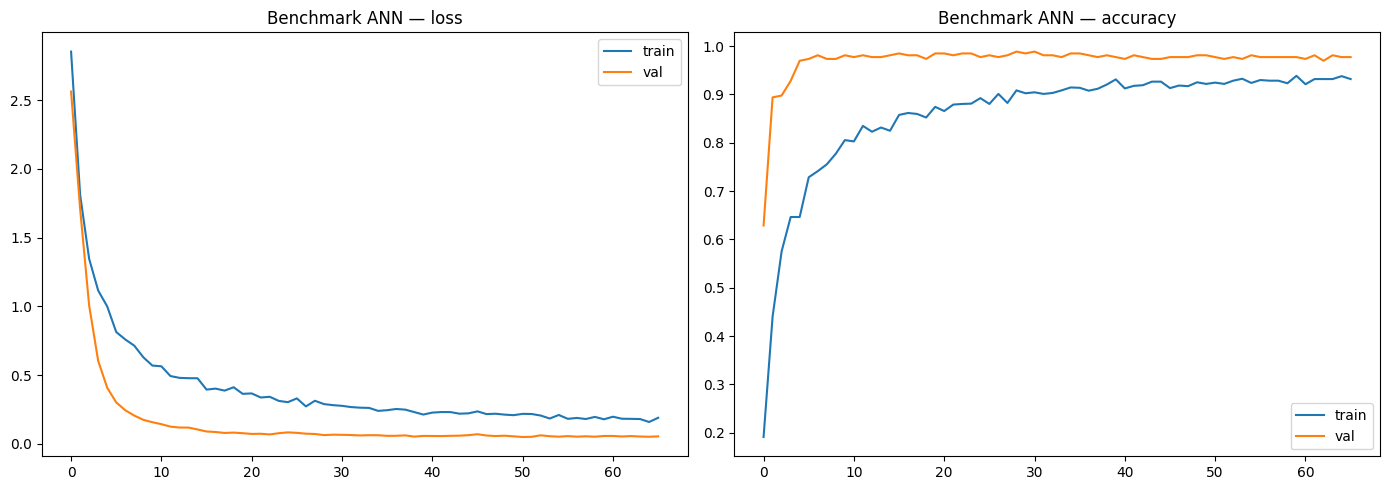

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(bench_history.history['loss'], label='train'); axes[0].plot(bench_history.history['val_loss'], label='val')
axes[0].set_title('Benchmark ANN — loss'); axes[0].legend()
axes[1].plot(bench_history.history['accuracy'], label='train'); axes[1].plot(bench_history.history['val_accuracy'], label='val')
axes[1].set_title('Benchmark ANN — accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/04_benchmark_ann_training.png', dpi=120)
plt.show()


In [6]:
yb_pred = bench_ann.predict(Xb_test, verbose=0).argmax(axis=1)
print('Test accuracy:', accuracy_score(yb_test, yb_pred))
print('\n', classification_report(yb_test, yb_pred, target_names=bench_label_encoder.classes_))


Test accuracy: 0.9818181818181818

               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.91      1.00      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      0.95      0.95        20
       maize       1.00      1.00      1.00        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.90      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       0.95      1.00      0.98        20
      orange       1.00      1.00      1.00  

## 2. Sri Lanka ANN (sri_lanka_crop_master.csv, 5 classes) — the production model

In [7]:
sl_split = np.load(f'{PROC_DIR}/srilanka_train_test_split.npz')
X_train, X_test, y_train, y_test = sl_split['X_train'], sl_split['X_test'], sl_split['y_train'], sl_split['y_test']
sl_label_encoder = joblib.load(f'{MODEL_DIR}/label_encoder_srilanka.pkl')
feature_cols = joblib.load(f'{MODEL_DIR}/feature_columns_srilanka.pkl')
n_classes_sl = len(sl_label_encoder.classes_)

print(X_train.shape, X_test.shape, n_classes_sl, 'classes:', list(sl_label_encoder.classes_))


(4680, 23) (1170, 23) 5 classes: ['Brinjal', 'Chilli', 'Onion', 'Pumpkin', 'Tomato']


In [8]:
sl_ann = build_ann(X_train.shape[1], n_classes_sl, hidden=(128, 64), dropout=0.35, lr=8e-4)
sl_ann.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,165 (47.52 KB)

 Trainable params: 11,909 (46.52 KB)

 Non-trainable params: 256 (1.00 KB)

In [9]:
class_weights = {}
counts = np.bincount(y_train)
total = counts.sum()
for c in range(len(counts)):
    class_weights[c] = total / (len(counts) * counts[c])
print('Class weights (to counter mild class imbalance):', class_weights)

early_stop_sl = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6)

sl_history = sl_ann.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=150,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop_sl, reduce_lr],
    verbose=0
)
print('Best val_accuracy:', max(sl_history.history['val_accuracy']))


Class weights (to counter mild class imbalance): {0: np.float64(0.8210526315789474), 1: np.float64(0.9873417721518988), 2: np.float64(1.3220338983050848), 3: np.float64(1.1304347826086956), 4: np.float64(0.8863636363636364)}


Best val_accuracy: 0.8917378783226013


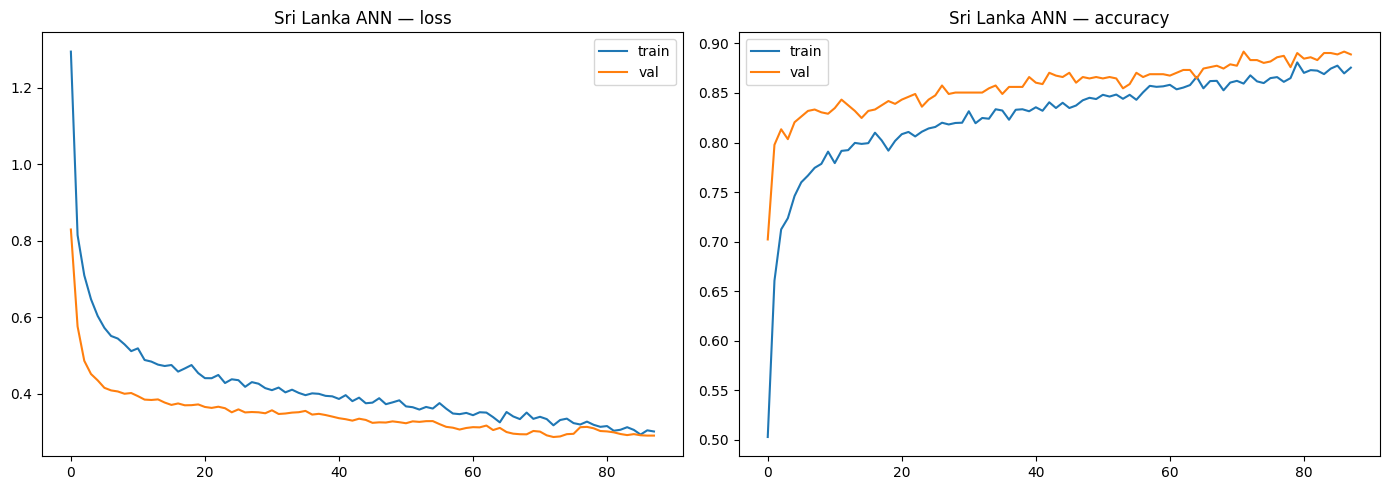

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(sl_history.history['loss'], label='train'); axes[0].plot(sl_history.history['val_loss'], label='val')
axes[0].set_title('Sri Lanka ANN — loss'); axes[0].legend()
axes[1].plot(sl_history.history['accuracy'], label='train'); axes[1].plot(sl_history.history['val_accuracy'], label='val')
axes[1].set_title('Sri Lanka ANN — accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/04_srilanka_ann_training.png', dpi=120)
plt.show()


In [11]:
y_pred = sl_ann.predict(X_test, verbose=0).argmax(axis=1)
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred, average='macro')
print(f'Test accuracy: {test_acc:.4f}   Macro F1: {test_f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=sl_label_encoder.classes_))


Test accuracy: 0.8897   Macro F1: 0.8838

              precision    recall  f1-score   support

     Brinjal       0.87      0.93      0.90       285
      Chilli       0.89      0.78      0.83       237
       Onion       0.83      0.87      0.85       177
     Pumpkin       0.86      0.86      0.86       207
      Tomato       0.99      0.98      0.98       264

    accuracy                           0.89      1170
   macro avg       0.89      0.88      0.88      1170
weighted avg       0.89      0.89      0.89      1170



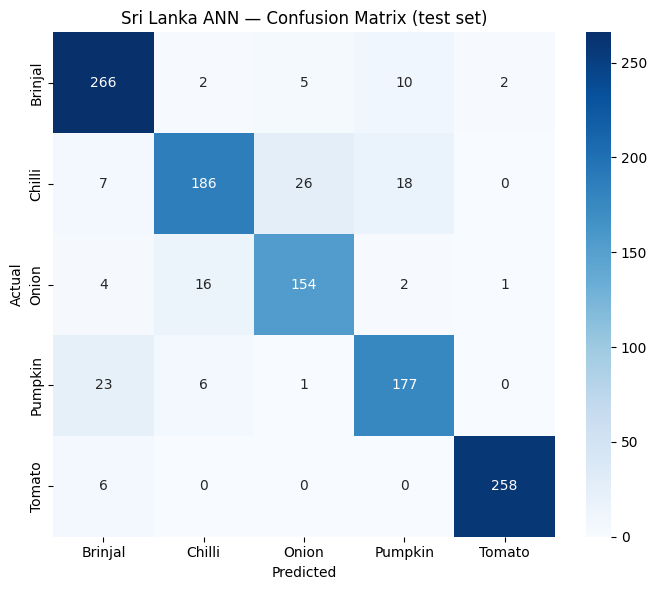

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sl_label_encoder.classes_, yticklabels=sl_label_encoder.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Sri Lanka ANN — Confusion Matrix (test set)')
plt.tight_layout()
plt.savefig('../outputs/04_srilanka_ann_confusion_matrix.png', dpi=120)
plt.show()


In [13]:
sl_ann.save(f'{MODEL_DIR}/ann_crop_recommender_srilanka.keras')
bench_ann.save(f'{MODEL_DIR}/ann_crop_recommender_benchmark.keras')
print('Models saved.')


Models saved.


## 3. Integration demo: recommend crops using **forecasted** future weather

This is the key decision-support capability: for a chosen district and season, combine
- the district's soil profile (from `soil_by_district.csv`)
- the LSTM-forecasted weather for a future month (from `weather_forecast_12m.csv`)

...into the exact feature vector the ANN expects, and get a crop recommendation with class
probabilities — a forward-looking recommendation rather than one based only on today's conditions.


In [14]:
scaler = joblib.load(f'{MODEL_DIR}/scaler_srilanka.pkl')
soil_by_district = pd.read_csv(f'{PROC_DIR}/soil_by_district.csv', index_col=0)
forecast = pd.read_csv(f'{PROC_DIR}/weather_forecast_12m.csv', parse_dates=['date'])

def recommend_crop(district, target_date, season, N, P, K, ph):
    """Recommend a crop using soil inputs (N,P,K,ph) + the FORECASTED weather for
    `target_date` in `district`, rather than only present-day conditions."""
    fc_row = forecast[(forecast['district'] == district) & (forecast['date'] == pd.Timestamp(target_date))]
    if fc_row.empty:
        raise ValueError(f'No forecast available for {district} on {target_date}. '
                          f'Available range: {forecast["date"].min()} to {forecast["date"].max()}')
    fc_row = fc_row.iloc[0]
    soil = soil_by_district.loc[district]

    row = {
        'N': N, 'P': P, 'K': K,
        'temperature': fc_row['temperature_avg_c'],
        'humidity': fc_row['humidity_percent'],
        'ph': ph,
        'rainfall': fc_row['rainfall_mm'],
        'soil_ph_texture': soil['soil_ph_texture'], 'soil_n_texture': soil['soil_n_texture'],
        'soil_clay': soil['soil_clay'], 'soil_sand': soil['soil_sand'], 'soil_silt': soil['soil_silt'],
        'soil_soc': soil['soil_soc'],
        'soil_ph_chem': soil.get('soil_ph_chem', ph), 'soil_n_chem': soil.get('soil_n_chem', N),
        'soil_p_chem': soil.get('soil_p_chem', P), 'soil_k_chem': soil.get('soil_k_chem', K),
        'soil_organic_c_pct': soil.get('soil_organic_c_pct', soil['soil_soc']),
        'soil_cec': soil.get('soil_cec', 15.0),
        'solar_rad': 18.0, 'wind_speed': 4.0,
        'season_Maha': 1 if season == 'Maha' else 0,
        'season_Yala': 1 if season == 'Yala' else 0,
    }
    vec = np.array([[row[c] for c in feature_cols]])
    vec_scaled = scaler.transform(vec)
    probs = sl_ann.predict(vec_scaled, verbose=0)[0]
    ranking = sorted(zip(sl_label_encoder.classes_, probs), key=lambda t: -t[1])
    return ranking

example = recommend_crop('Kandy', '2026-06-01', 'Yala', N=90, P=45, K=40, ph=6.3)
print('Forecast-based recommendation for Kandy, June 2026 (Yala season):')
for crop, prob in example:
    print(f'  {crop:10s} {prob*100:5.1f}%')


Forecast-based recommendation for Kandy, June 2026 (Yala season):
  Onion       99.9%
  Tomato       0.1%
  Chilli       0.0%
  Pumpkin      0.0%
  Brinjal      0.0%


/tmp/ipykernel_2782/2166678790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(probs), y=list(crops), palette='viridis', ax=ax)


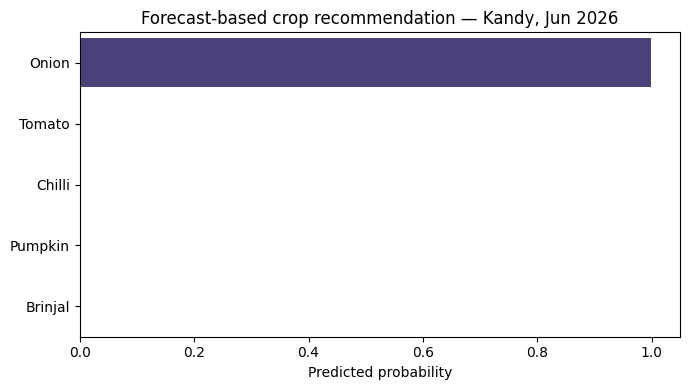

In [15]:
fig, ax = plt.subplots(figsize=(7,4))
crops, probs = zip(*example)
sns.barplot(x=list(probs), y=list(crops), palette='viridis', ax=ax)
ax.set_xlabel('Predicted probability'); ax.set_title('Forecast-based crop recommendation — Kandy, Jun 2026')
plt.tight_layout()
plt.savefig('../outputs/04_forecast_based_recommendation_example.png', dpi=120)
plt.show()


## 4. Summary

- Both the benchmark and Sri-Lanka-specific ANNs were trained successfully; metrics are reported
  above and are compared against classical ML models in `05_ml_model_comparison.ipynb`.
- `recommend_crop()` demonstrates the full pipeline required by the web app: soil inputs (measured
  or looked up per district) + **forecasted** weather (from the LSTM in notebook 03) → ANN → ranked
  crop recommendations with probabilities.
- Trained models saved to `models/ann_crop_recommender_srilanka.keras` and
  `models/ann_crop_recommender_benchmark.keras`.

**Next step →** `05_ml_model_comparison.ipynb` benchmarks this ANN against Logistic Regression,
Decision Tree, Random Forest, SVM, KNN and Gradient Boosting on the same Sri-Lanka dataset.
